
## **Problem Statement**

The organization has provided three datasets: **2024 sales records, 2025 sales records, and a manager dataset**. The goal of this project is to **clean, consolidate, and analyze the sales data** to uncover insights into revenue generation, product performance, and transaction patterns.

The specific tasks include:

1. **Data Cleaning and Preparation**

   * Identify and remove **duplicate records** using the Transaction ID as a unique identifier.
   * Standardize text fields, trim unnecessary spaces, and correct inconsistencies in columns such as Product, Payment Method, and Transaction Rating.
   * Create a **new column mapping numerical ratings to textual experiences**, where:

     | Rating | Experience |
     | ------ | ---------- |
     | 5      | Excellent  |
     | 4      | Very Good  |
     | 3      | Good       |
     | 2      | Poor       |
     | 1      | Very Poor  |

2. **Data Consolidation**

   * Combine the 2024 and 2025 datasets into a **single consolidated table** using append operations.
   * Integrate the manager dataset where relevant to associate sales with their respective managers.

3. **Analysis Objectives**

   * Calculate **key metrics**: total sales revenue, quantity sold, average amount sold, and average transaction rating.
   * Identify the **manager with the highest total sales revenue in 2025**.
   * Determine the **top 2 products by total revenue**.
   * Analyze **sales trends over time** by month to identify patterns or seasonality.
   * Identify the **top 5 sales representatives by total revenue**.
   * Determine which **product has the highest average transaction rating**.
   * Determine which **payment method is most frequently associated with Excellent transaction ratings**.

This analysis will provide actionable insights into sales performance, product popularity, customer satisfaction, and revenue drivers, enabling data-driven decision-making for future business strategies.

In [1]:
# Importing required Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore") 

In [2]:
# reading the data and getting a view
data=pd.read_excel("Sales(2025).xlsx")
data.head(5)

,Transaction ID,Transaction Date,Customer Name,Email,Phone Number,State,Product,Sales Amount,Quantity,Payment Method,Sales Rep,Customer Type,Transaction Rating,Notes
0,TXN-1486,2025-05-05,Samuel Lawal,samuel.lawal@example.com,,Port Harcourt,Laptop,124829,18,Card,Paul Ojo,Retail,5,repeat customer
1,TXN-1123,2025-10-02,John Ade,john.ade@example.com,+2348920318171,Abuja,Laptop,30405,6,Card,Paul Ahmed,Retail,4,NaN
2,TXN-1385,2025-10-26,Samuel Brown,samuel.brown@example.com,+2348523205280,Abuja,Accessories,70197,4,Cash,James Adeyemi,Corporate,2,NaN
3,TXN-1112,2025-12-02,Fatima Lawal,fatima.lawal@example.com,+2349000916720,Port Harcourt,Tablet,159025,11,Transfer,Michael Johnson,retail,5,NaN
4,TXN-1141,2025-05-05,Ada Ade,ada.ade@example.com,+2348489748681,Abuja,Accessories,248519,18,cash,James Ojo,Retail,3,repeat customer


### Data Cleaning

In [3]:
# viewing a summary
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1729 entries, 0 to 1728
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction ID      1729 non-null   object        
 1   Transaction Date    1729 non-null   datetime64[ns]
 2   Customer Name       1729 non-null   object        
 3   Email               1459 non-null   object        
 4   Phone Number        1729 non-null   object        
 5   State               1729 non-null   object        
 6   Product             1729 non-null   object        
 7   Sales Amount        1729 non-null   int64         
 8   Quantity            1729 non-null   int64         
 9   Payment Method      1729 non-null   object        
 10  Sales Rep           1729 non-null   object        
 11  Customer Type       1729 non-null   object        
 12  Transaction Rating  1729 non-null   int64         
 13  Notes               863 non-null    object      

#### From the above we can see that the email and notes column are missing some values. 
There are also empty spaces that aren't recognized as null values or nan across the dataset
We will replace the empty strings with nan and remove the empty spaces

In [4]:
# Strip spaces and replace empty strings with NaN
for col in data.columns:
    if data[col].dtype == "object":
        data[col]=data[col].str.strip()
        data[col]=data[col].replace('',np.nan)

#### The duplicate records in the dataset will also be removed using the transaction id as criteria

In [5]:
# remove duplicates based on id
data=data.drop_duplicates(subset=["Transaction ID"], keep="first")

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 486 entries, 0 to 1712
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction ID      486 non-null    object        
 1   Transaction Date    486 non-null    datetime64[ns]
 2   Customer Name       486 non-null    object        
 3   Email               418 non-null    object        
 4   Phone Number        382 non-null    object        
 5   State               486 non-null    object        
 6   Product             486 non-null    object        
 7   Sales Amount        486 non-null    int64         
 8   Quantity            486 non-null    int64         
 9   Payment Method      486 non-null    object        
 10  Sales Rep           486 non-null    object        
 11  Customer Type       486 non-null    object        
 12  Transaction Rating  486 non-null    int64         
 13  Notes               233 non-null    object        
dty

**Some rows are missing in the phone number and email columns but we don't have to drop the rows since our goal isn't tied to those columns** 

**The dataset also has some columns having different forms of text for one category view them below**

In [7]:
# data["State"].unique()
# data["Product"].unique()
# data["Customer Type"].unique()
# data["Payment Method"].unique()

**We will be cleaning these columns by using one categorical label across them**

In [8]:
# cleaning the state column
data["State"]=data["State"].replace({
    "PH":"Port Harcourt",
    "ABUJA":"Abuja",
    "lagos":"Lagos"
})
# cleaning the payment method column
data["Payment Method"]=data["Payment Method"].replace({
    "cash":"Cash"})
# cleaning the product column
data["Product"]=data["Product"].replace("PHONE","Phone")
# cleaning the customer type column
data["Customer Type"]=data["Customer Type"].replace({
    "retail":"Retailer",
    "Retail":"Retailer",
    "CORPORATE":"Corporate"})

### The same steps will be added to the second dataset

In [9]:
data2=pd.read_excel("Sales(2024).xlsx")
data2.head()

,Transaction ID,Transaction Date,Customer Name,Email,Phone Number,State,Product,Sales Amount,Quantity,Payment Method,Sales Rep,Customer Type,Transaction Rating,Notes
0,TXN-1308,2024-01-18,Fatima Johnson,fatima.johnson@example.com,,ABUJA,Phone,56779,16,Transfer,James Johnson,CORPORATE,4,NaN
1,TXN-1038,2024-06-10,Musa Williams,musa.williams@example.com,+2347622937604,Port Harcourt,Accessories,184200,7,cash,Paul Adeyemi,Retail,4,Follow-up needed!!!
2,TXN-1426,2024-07-02,Aisha Johnson,aisha.johnson@example.com,,Abuja,PHONE,27991,18,Transfer,Michael Ahmed,retail,2,NaN
3,TXN-1064,2024-01-25,Samuel Lawal,samuel.lawal@example.com,+2348374282205,Port Harcourt,Laptop,166372,2,Card,Ibrahim Adeyemi,retail,5,Urgent delivery
4,TXN-1285,2024-03-26,Fatima Lawal,NaN,,Abuja,PHONE,139640,11,Transfer,Michael Ahmed,Corporate,4,NaN


In [10]:
for col in data2:
    if data2[col].dtype== object:
        data2[col]=data2[col].str.strip()
        data2[col]=data2[col].replace("",np.nan)

In [11]:
data2=data2.drop_duplicates(subset="Transaction ID",keep="first")

In [12]:
data2["State"]=data2["State"].replace({
    "PH":"Port Harcourt",
    "ABUJA":"Abuja",
    "lagos":"Lagos"
})
data2["Product"]=data2["Product"].replace("PHONE","Phone")
data2["Payment Method"]=data2["Payment Method"].replace({
    "cash":"Cash"
})
data2["Customer Type"]=data2["Customer Type"].replace({
    "retail":"Retailer",
    "Retail":"Retailer",
    "CORPORATE":"Corporate"})

**Now that the datasets are clean we will join both so we can work on both at once**

In [13]:
# joining both datasets
combined_df= pd.concat([data,data2],ignore_index=True)

In [14]:
combined_df.head(5)

,Transaction ID,Transaction Date,Customer Name,Email,Phone Number,State,Product,Sales Amount,Quantity,Payment Method,Sales Rep,Customer Type,Transaction Rating,Notes
0,TXN-1486,2025-05-05,Samuel Lawal,samuel.lawal@example.com,NaN,Port Harcourt,Laptop,124829,18,Card,Paul Ojo,Retailer,5,repeat customer
1,TXN-1123,2025-10-02,John Ade,john.ade@example.com,+2348920318171,Abuja,Laptop,30405,6,Card,Paul Ahmed,Retailer,4,NaN
2,TXN-1385,2025-10-26,Samuel Brown,samuel.brown@example.com,+2348523205280,Abuja,Accessories,70197,4,Cash,James Adeyemi,Corporate,2,NaN
3,TXN-1112,2025-12-02,Fatima Lawal,fatima.lawal@example.com,+2349000916720,Port Harcourt,Tablet,159025,11,Transfer,Michael Johnson,Retailer,5,NaN
4,TXN-1141,2025-05-05,Ada Ade,ada.ade@example.com,+2348489748681,Abuja,Accessories,248519,18,Cash,James Ojo,Retailer,3,repeat customer


#### Now we will use the map function to categorize the ratings as Excellent, Good.... and also the Managers based on their states

In [15]:
# Categorizing ratings
combined_df["Experience"] = combined_df["Transaction Rating"].map({
    5: "Excellent",
    4: "Very Good",
    3: "Good",
    2: "Poor",
    1: "Very Poor"
})
combined_df["Manager"]=combined_df["State"].map({
    "Lagos":"Babatunde Ahmed",
    "Abuja":"Uche Otedola",
    "Port Harcourt":"Kenneth Fadeyi"
})

combined_df.head(5)

,Transaction ID,Transaction Date,Customer Name,Email,Phone Number,State,Product,Sales Amount,Quantity,Payment Method,Sales Rep,Customer Type,Transaction Rating,Notes,Experience,Manager
0,TXN-1486,2025-05-05,Samuel Lawal,samuel.lawal@example.com,NaN,Port Harcourt,Laptop,124829,18,Card,Paul Ojo,Retailer,5,repeat customer,Excellent,Kenneth Fadeyi
1,TXN-1123,2025-10-02,John Ade,john.ade@example.com,+2348920318171,Abuja,Laptop,30405,6,Card,Paul Ahmed,Retailer,4,NaN,Very Good,Uche Otedola
2,TXN-1385,2025-10-26,Samuel Brown,samuel.brown@example.com,+2348523205280,Abuja,Accessories,70197,4,Cash,James Adeyemi,Corporate,2,NaN,Poor,Uche Otedola
3,TXN-1112,2025-12-02,Fatima Lawal,fatima.lawal@example.com,+2349000916720,Port Harcourt,Tablet,159025,11,Transfer,Michael Johnson,Retailer,5,NaN,Excellent,Kenneth Fadeyi
4,TXN-1141,2025-05-05,Ada Ade,ada.ade@example.com,+2348489748681,Abuja,Accessories,248519,18,Cash,James Ojo,Retailer,3,repeat customer,Good,Uche Otedola


*Our goal requires yearly data so we'll add a new column Year* 

In [16]:
# Adding the Year column
combined_df["Year"]=combined_df["Transaction Date"].dt.year

### Solution to the Objectives

In [17]:
# total revenue
combined_df["Sales Amount"].sum()
# quantity sold
combined_df["Quantity"].sum()
# average amount sold
combined_df["Quantity"].mean()
# average transaction rating
combined_df["Transaction Rating"].mean()
# top manager
top_manager=combined_df.groupby(["Year","Manager"])["Sales Amount"].sum()[2025].idxmax()
# top products
top_products=combined_df.groupby("Product")["Sales Amount"].sum().sort_values(ascending=False).head(2)
# top sales rep
top_sales_rep=combined_df.groupby("Sales Rep")["Sales Amount"].sum().sort_values(ascending=False).head(5)
# top average rating
top_average_rating=combined_df.groupby("Product")["Transaction Rating"].mean().idxmax()
# top payment method
top_payment_method=combined_df.groupby(["Experience","Payment Method"]).size()["Excellent"].idxmax()

### Function to print the results 

In [18]:
def summarize_sales(df):
    """Print key sales performance metrics from the consolidated dataframe."""

    # ── Key Metrics ───────────────────────────────────────────────────────
    total_revenue   = df["Sales Amount"].sum()
    total_qty       = df["Quantity"].sum()
    avg_amount      = df["Sales Amount"].mean()
    avg_rating      = df["Transaction Rating"].mean()

    # ── Aggregations ──────────────────────────────────────────────────────
    top_manager      = df.groupby(["Year","Manager"])["Sales Amount"].sum()[2025].idxmax()
    top_products     = df.groupby("Product")["Sales Amount"].sum().sort_values(ascending=False).head(2)
    top_sales_rep    = df.groupby("Sales Rep")["Sales Amount"].sum().sort_values(ascending=False).head(5)
    top_avg_rating   = df.groupby("Product")["Transaction Rating"].mean().idxmax()
    top_payment      = df.groupby(["Experience","Payment Method"]).size()["Excellent"].idxmax()

    # ── Print Output ──────────────────────────────────────────────────────
    print("=" * 50)
    print("       SALES PERFORMANCE SUMMARY")
    print("=" * 50)

    print(f"\n📦 Total Revenue:            ₦{total_revenue:,.2f}")
    print(f"🛒 Total Quantity Sold:       {total_qty:,} units")
    print(f"💵 Average Transaction Value: ₦{avg_amount:,.2f}")
    print(f"⭐ Average Transaction Rating: {avg_rating:.2f} / 5")

    print("\n" + "-" * 50)
    print(f"🏆 Top Manager (2025):        {top_manager}")
    print(f"💳 Top Payment Method         ")
    print(f"   (Excellent Ratings):       {top_payment}")
    print(f"🌟 Product w/ Highest         ")
    print(f"   Avg Rating:                {top_avg_rating}")

    print("\n" + "-" * 50)
    print("🥇 Top 2 Products by Revenue:")
    for rank, (product, revenue) in enumerate(top_products.items(), start=1):
        print(f"   {rank}. {product:<15} ₦{revenue:,.2f}")

    print("\n" + "-" * 50)
    print("👤 Top 5 Sales Reps by Revenue:")
    for rank, (rep, revenue) in enumerate(top_sales_rep.items(), start=1):
        print(f"   {rank}. {rep:<20} ₦{revenue:,.2f}")

    print("=" * 50)


# ── Call the function ──────────────────────────────────────────────────────
summarize_sales(combined_df)

       SALES PERFORMANCE SUMMARY

📦 Total Revenue:            ₦119,957,034.00
🛒 Total Quantity Sold:       9,318 units
💵 Average Transaction Value: ₦133,731.36
⭐ Average Transaction Rating: 3.72 / 5

--------------------------------------------------
🏆 Top Manager (2025):        Uche Otedola
💳 Top Payment Method         
   (Excellent Ratings):       Cash
🌟 Product w/ Highest         
   Avg Rating:                Phone

--------------------------------------------------
🥇 Top 2 Products by Revenue:
   1. Phone           ₦45,793,602.00
   2. Accessories     ₦27,998,818.00

--------------------------------------------------
👤 Top 5 Sales Reps by Revenue:
   1. Zainab Okeke         ₦4,146,602.00
   2. Michael Adeyemi      ₦3,646,944.00
   3. Ibrahim Adeyemi      ₦3,533,293.00
   4. Mary Adeyemi         ₦3,412,460.00
   5. Ibrahim Okeke        ₦3,390,006.00


### Data Visualization

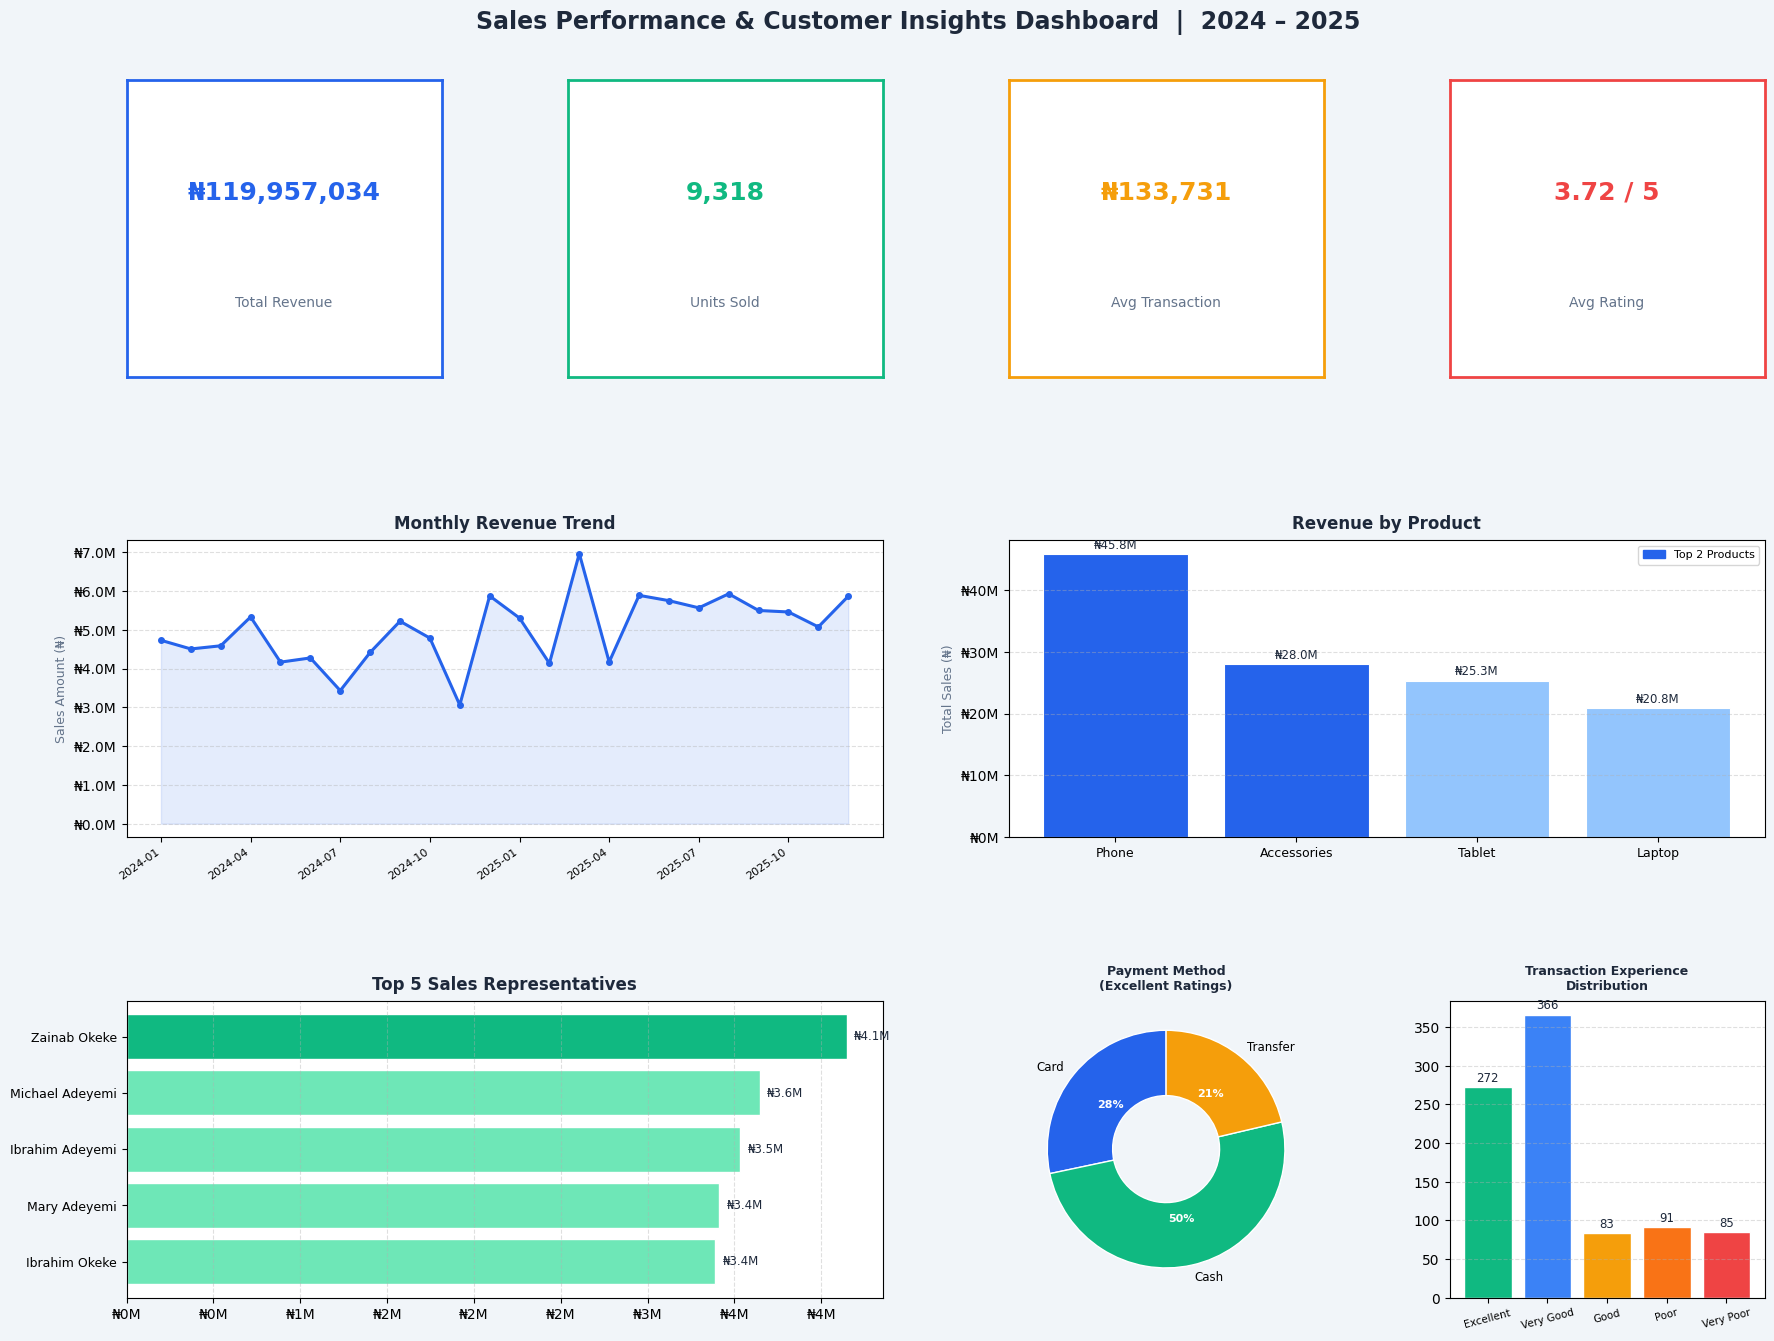

✅ Dashboard saved as sales_dashboard.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ── Derived data for charts ────────────────────────────────────────────────
# Key Metrics
total_revenue     = combined_df["Sales Amount"].sum()
total_qty         = combined_df["Quantity"].sum()
avg_amount        = combined_df["Sales Amount"].mean()
avg_rating        = combined_df["Transaction Rating"].mean()

# Product revenue
product_revenue = (
    combined_df.groupby("Product")["Sales Amount"]
    .sum()
    .sort_values(ascending=False)
)

# Monthly sales trend (both years combined)
combined_df["Month"] = combined_df["Transaction Date"].dt.to_period("M")
monthly_sales = (
    combined_df.groupby("Month")["Sales Amount"]
    .sum()
    .sort_index()
)
month_labels = [str(m) for m in monthly_sales.index]

# Top 5 Sales Reps
top_reps = (
    combined_df.groupby("Sales Rep")["Sales Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# Payment method split for Excellent ratings
excellent_payment = (
    combined_df[combined_df["Experience"] == "Excellent"]
    .groupby("Payment Method")
    .size()
)

# Experience distribution
experience_counts = combined_df["Experience"].value_counts().reindex(
    ["Excellent", "Very Good", "Good", "Poor", "Very Poor"]
)

# ── Colour palette ────────────────────────────────────────────────────────
PRIMARY   = "#2563EB"   # blue
SECONDARY = "#10B981"   # green
ACCENT    = "#F59E0B"   # amber
DANGER    = "#EF4444"   # red
LIGHT_BG  = "#F1F5F9"
CARD_BG   = "#FFFFFF"
TEXT      = "#1E293B"

exp_colors = {
    "Excellent": "#10B981",
    "Very Good": "#3B82F6",
    "Good":      "#F59E0B",
    "Poor":      "#F97316",
    "Very Poor": "#EF4444",
}

# ── Figure layout ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14), facecolor=LIGHT_BG)
fig.suptitle(
    "Sales Performance & Customer Insights Dashboard  |  2024 – 2025",
    fontsize=17, fontweight="bold", color=TEXT, y=0.98
)

gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    hspace=0.55, wspace=0.4,
    top=0.93, bottom=0.06, left=0.06, right=0.97
)

# ── Row 0 — KPI cards (4 tiles) ───────────────────────────────────────────
kpis = [
    ("Total Revenue",     f"₦{total_revenue:,.0f}",  PRIMARY),
    ("Units Sold",        f"{total_qty:,}",            SECONDARY),
    ("Avg Transaction",   f"₦{avg_amount:,.0f}",      ACCENT),
    ("Avg Rating",        f"{avg_rating:.2f} / 5",    DANGER),
]
for col, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor(CARD_BG)
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.62, value, ha="center", va="center",
            fontsize=18, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha="center", va="center",
            fontsize=10, color="#64748B", transform=ax.transAxes)

# ── Row 1 left (span 2) — Monthly revenue trend ───────────────────────────
ax_trend = fig.add_subplot(gs[1, :2])
ax_trend.set_facecolor(CARD_BG)
ax_trend.plot(range(len(monthly_sales)), monthly_sales.values,
              color=PRIMARY, linewidth=2.2, marker="o", markersize=4)
ax_trend.fill_between(range(len(monthly_sales)), monthly_sales.values,
                       alpha=0.12, color=PRIMARY)
step = max(1, len(month_labels) // 8)
ax_trend.set_xticks(range(0, len(month_labels), step))
ax_trend.set_xticklabels(month_labels[::step], rotation=35, ha="right", fontsize=8)
ax_trend.set_title("Monthly Revenue Trend", fontweight="bold", color=TEXT, pad=8)
ax_trend.set_ylabel("Sales Amount (₦)", fontsize=9, color="#64748B")
ax_trend.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"₦{x/1e6:.1f}M")
)
ax_trend.grid(axis="y", linestyle="--", alpha=0.4)
ax_trend.set_facecolor(CARD_BG)

# ── Row 1 right (span 2) — Product revenue bar ────────────────────────────
ax_prod = fig.add_subplot(gs[1, 2:])
ax_prod.set_facecolor(CARD_BG)
colors_prod = [PRIMARY if i < 2 else "#93C5FD" for i in range(len(product_revenue))]
bars = ax_prod.bar(product_revenue.index, product_revenue.values,
                   color=colors_prod, edgecolor="white", linewidth=0.8)
for bar in bars:
    ax_prod.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + product_revenue.max() * 0.01,
                 f"₦{bar.get_height()/1e6:.1f}M",
                 ha="center", va="bottom", fontsize=8.5, color=TEXT)
ax_prod.set_title("Revenue by Product", fontweight="bold", color=TEXT, pad=8)
ax_prod.set_ylabel("Total Sales (₦)", fontsize=9, color="#64748B")
ax_prod.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"₦{x/1e6:.0f}M")
)
ax_prod.tick_params(axis="x", labelsize=9)
ax_prod.grid(axis="y", linestyle="--", alpha=0.4)
top2_patch = mpatches.Patch(color=PRIMARY, label="Top 2 Products")
ax_prod.legend(handles=[top2_patch], fontsize=8)

# ── Row 2 left — Top 5 Sales Reps horizontal bar ─────────────────────────
ax_reps = fig.add_subplot(gs[2, :2])
ax_reps.set_facecolor(CARD_BG)
rep_colors = [SECONDARY if i == 0 else "#6EE7B7" for i in range(len(top_reps))]
ax_reps.barh(top_reps.index[::-1], top_reps.values[::-1],
             color=rep_colors[::-1], edgecolor="white")
for i, (val, name) in enumerate(zip(top_reps.values[::-1], top_reps.index[::-1])):
    ax_reps.text(val + top_reps.max() * 0.01, i,
                 f"₦{val/1e6:.1f}M", va="center", fontsize=8.5, color=TEXT)
ax_reps.set_title("Top 5 Sales Representatives", fontweight="bold", color=TEXT, pad=8)
ax_reps.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"₦{x/1e6:.0f}M")
)
ax_reps.tick_params(axis="y", labelsize=9)
ax_reps.grid(axis="x", linestyle="--", alpha=0.4)

# ── Row 2 mid — Payment method for Excellent ratings (donut) ─────────────
ax_pay = fig.add_subplot(gs[2, 2])
ax_pay.set_facecolor(CARD_BG)
pay_colors = [PRIMARY, SECONDARY, ACCENT, DANGER][:len(excellent_payment)]
wedges, texts, autotexts = ax_pay.pie(
    excellent_payment.values,
    labels=excellent_payment.index,
    autopct="%1.0f%%",
    colors=pay_colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white"),
    textprops=dict(fontsize=8.5),
)
for at in autotexts:
    at.set_fontsize(8); at.set_color("white"); at.set_fontweight("bold")
ax_pay.set_title("Payment Method\n(Excellent Ratings)", fontweight="bold",
                 color=TEXT, pad=8, fontsize=9)

# ── Row 2 right — Experience distribution (stacked bar-like) ─────────────
ax_exp = fig.add_subplot(gs[2, 3])
ax_exp.set_facecolor(CARD_BG)
exp_vals   = experience_counts.values
exp_labels = experience_counts.index
bar_colors = [exp_colors[e] for e in exp_labels]
ax_exp.bar(exp_labels, exp_vals, color=bar_colors, edgecolor="white")
for i, v in enumerate(exp_vals):
    ax_exp.text(i, v + max(exp_vals) * 0.02, str(v),
                ha="center", fontsize=8.5, color=TEXT)
ax_exp.set_title("Transaction Experience\nDistribution", fontweight="bold",
                 color=TEXT, pad=8, fontsize=9)
ax_exp.tick_params(axis="x", labelsize=7.5, rotation=15)
ax_exp.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("sales_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=LIGHT_BG)
plt.show()
print("✅ Dashboard saved as sales_dashboard.png")

---

## 👤 Author

**Tanimowo Possible**

🔗 [LinkedIn](https://www.linkedin.com/in/tanimowo-possible/)  
💻 [GitHub](https://github.com/positanny13/)

---